# Import the Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Import the Salaries.csv dataset

In [11]:
data_url = 'http://vincentarelbundock.github.io/Rdatasets/csv/carData/Salaries.csv'
df = pd.read_csv(data_url, index_col =0 )
df

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
rownames,,,,,,
1,Prof,B,19,18,Male,139750
2,Prof,B,20,16,Male,173200
3,AsstProf,B,4,3,Male,79750
4,Prof,B,45,39,Male,115000
5,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...
393,Prof,A,33,30,Male,103106
394,Prof,A,31,19,Male,150564
395,Prof,A,42,25,Male,101738


In [12]:
df_dummies = pd.get_dummies(df[['rank','sex','discipline']],prefix = '', prefix_sep ='')
df_dummies.head()

,AssocProf,AsstProf,Prof,Female,Male,A,B
rownames,,,,,,,
1,False,False,True,False,True,False,True
2,False,False,True,False,True,False,True
3,False,True,False,False,True,False,True
4,False,False,True,False,True,False,True
5,False,False,True,False,True,False,True


In [13]:
df.shape

(397, 6)

# Create the dummy variables for categorical features

In [14]:
df_dummies = pd.get_dummies(df[['rank','sex','discipline']],prefix = '', prefix_sep ='', drop_first=True)
df_dummies.head()

,AsstProf,Prof,Male,B
rownames,,,,
1,False,True,True,True
2,False,True,True,True
3,True,False,True,True
4,False,True,True,True
5,False,True,True,True


# Concatenate the dummy variables to the original dataset

In [15]:
df2 = pd.concat([df,df_dummies], axis = 1)
df2

,rank,discipline,yrs.since.phd,yrs.service,sex,salary,AsstProf,Prof,Male,B
rownames,,,,,,,,,,
1,Prof,B,19,18,Male,139750,False,True,True,True
2,Prof,B,20,16,Male,173200,False,True,True,True
3,AsstProf,B,4,3,Male,79750,True,False,True,True
4,Prof,B,45,39,Male,115000,False,True,True,True
5,Prof,B,40,41,Male,141500,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
393,Prof,A,33,30,Male,103106,False,True,True,False
394,Prof,A,31,19,Male,150564,False,True,True,False
395,Prof,A,42,25,Male,101738,False,True,True,False


## Drop rank, sex and discipline columns because their dummy variables have been created

In [16]:
df2.drop(['rank','sex','discipline'], axis = 1, inplace = True)

In [9]:
df2

,yrs.since.phd,yrs.service,salary,AsstProf,Prof,Male,B
rownames,,,,,,,
1,19,18,139750,False,True,True,True
2,20,16,173200,False,True,True,True
3,4,3,79750,True,False,True,True
4,45,39,115000,False,True,True,True
5,40,41,141500,False,True,True,True
...,...,...,...,...,...,...,...
393,33,30,103106,False,True,True,False
394,31,19,150564,False,True,True,False
395,42,25,101738,False,True,True,False


# Using Multilinear Regression, predict the salary from the given independent features

In [17]:
X = df2.drop(['salary'], axis = 1)
X = sm.add_constant(X)  # Add a constant term for the intercept

X

,const,yrs.since.phd,yrs.service,AsstProf,Prof,Male,B
rownames,,,,,,,
1,1.0,19,18,False,True,True,True
2,1.0,20,16,False,True,True,True
3,1.0,4,3,True,False,True,True
4,1.0,45,39,False,True,True,True
5,1.0,40,41,False,True,True,True
...,...,...,...,...,...,...,...
393,1.0,33,30,False,True,True,False
394,1.0,31,19,False,True,True,False
395,1.0,42,25,False,True,True,False


In [18]:
y = df2['salary']

In [19]:
y

,salary
rownames,
1,139750
2,173200
3,79750
4,115000
5,141500
...,...
393,103106
394,150564
395,101738


In [20]:
# Fit the regression model
model = sm.OLS(y, X.astype(float)).fit()

# Print the summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     54.20
Date:                Mon, 12 May 2025   Prob (F-statistic):           1.79e-48
Time:                        13:29:59   Log-Likelihood:                -4538.9
No. Observations:                 397   AIC:                             9092.
Df Residuals:                     390   BIC:                             9120.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7.886e+04   4990.326     15.803

In [21]:
# Get residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

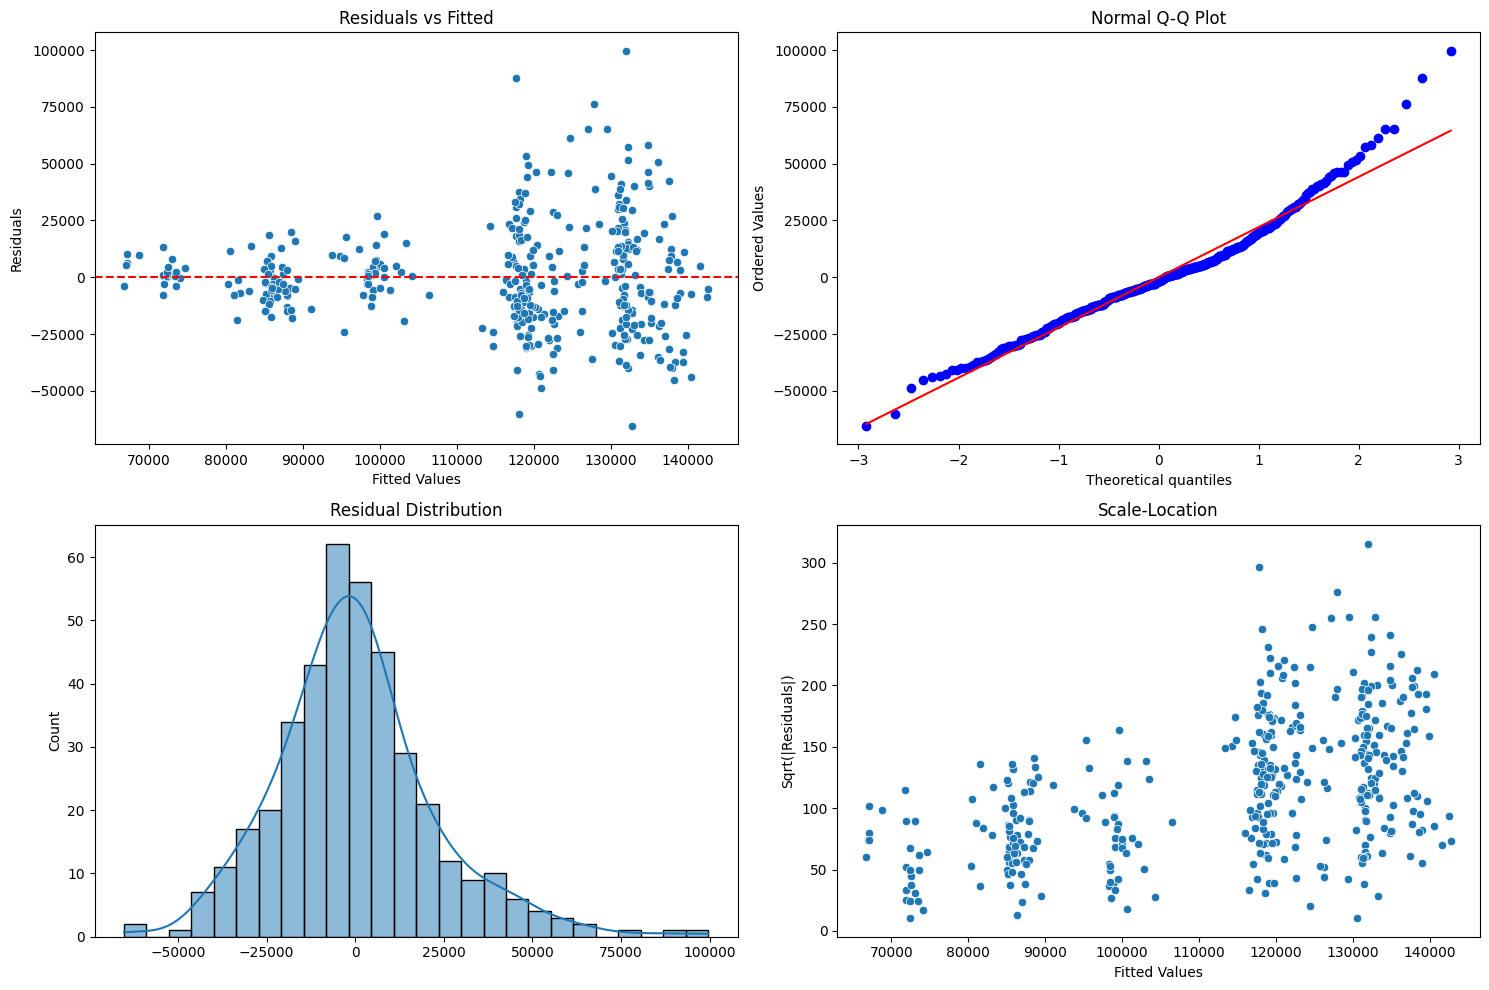

In [23]:
import seaborn as sns
# Create subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1,0])
axes[1,0].set_title('Residual Distribution')

# 4. Scale-Location Plot
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), ax=axes[1,1])
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Machine Learning Approach

In [24]:
X = df2.drop(['salary'], axis = 1).values
y = df2['salary'].values.reshape(-1, 1)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 42)

In [26]:
X_train

array([[37, 27, False, True, True, False],
       [7, 2, True, False, True, True],
       [39, 38, False, True, True, False],
       ...,
       [42, 40, False, True, True, False],
       [4, 3, True, False, True, True],
       [16, 5, False, True, True, True]], dtype=object)

In [27]:
y_train

array([[103600],
       [ 91300],
       [136500],
       [ 73000],
       [125196],
       [ 79800],
       [ 89650],
       [134000],
       [119500],
       [ 72500],
       [ 92000],
       [168500],
       [ 73800],
       [117515],
       [101036],
       [ 93000],
       [172505],
       [ 81800],
       [ 86895],
       [ 88795],
       [109000],
       [108262],
       [ 92000],
       [114500],
       [ 92000],
       [186023],
       [ 79750],
       [165000],
       [120806],
       [ 73300],
       [ 69700],
       [134885],
       [115313],
       [144050],
       [ 87800],
       [ 84500],
       [134800],
       [110515],
       [124312],
       [ 72500],
       [113398],
       [104428],
       [118223],
       [ 88825],
       [ 93519],
       [ 82600],
       [ 91100],
       [136660],
       [ 72500],
       [ 84273],
       [101000],
       [ 72300],
       [ 94384],
       [205500],
       [100522],
       [107300],
       [132825],
       [102600],
       [103750

In [28]:
X_test

array([[12, 0, False, True, False, False],
       [24, 18, False, True, True, False],
       [7, 6, True, False, False, False],
       ...,
       [31, 28, False, True, True, False],
       [26, 22, False, True, True, True],
       [39, 9, False, True, True, False]], dtype=object)

In [29]:
y_test

array([[105000],
       [107100],
       [ 63100],
       [ 90215],
       [100131],
       [ 83600],
       [ 92391],
       [ 88000],
       [103994],
       [109954],
       [129000],
       [119450],
       [126933],
       [126320],
       [134690],
       [100000],
       [101299],
       [ 78500],
       [ 57800],
       [ 92700],
       [117150],
       [128800],
       [151650],
       [139750],
       [ 83850],
       [121946],
       [ 86100],
       [ 80225],
       [117555],
       [148800],
       [122960],
       [105450],
       [ 98053],
       [117704],
       [193000],
       [162221],
       [107550],
       [134185],
       [134550],
       [ 76840],
       [106294],
       [ 94350],
       [ 83900],
       [114330],
       [144651],
       [150480],
       [123683],
       [ 98193],
       [ 67559],
       [144640],
       [101100],
       [100938],
       [204000],
       [ 97032],
       [132261],
       [ 85000],
       [142467],
       [ 88175],
       [130664

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
Model_Reg = LinearRegression()

In [32]:
Model_Reg.fit(X_train, y_train)

LinearRegression()

In [33]:
print(Model_Reg.coef_, Model_Reg.intercept_)

[[ 2.38839424e+02 -3.03241821e+01 -1.19178309e+04  3.32431130e+04
   3.79609739e+03  1.73618049e+04]] [76420.45931684]


In [34]:
y_pred = Model_Reg.predict(X_test)

In [35]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

RMSE: 22995.151146246153
MAE: 17017.397752305376
R2: 0.3719379192364527
